# Week 2 Capstone: Function-by-function review

## Table of contents

1. [Overview](#overview)
2. [Objectives](#objectives)
3. [Evidence provenance](#evidence-provenance)
4. [Environment and setup](#environment-setup)
5. [Data validation](#data-validation)
6. [Descriptive EDA](#descriptive-eda)
7. [Visual EDA](#visual-eda)
8. [GP model configuration](#gp-model-configuration)
9. [GP-UCB values](#gp-ucb-values)
10. [Reproducibility checks](#reproducibility-checks)
11. [Conclusions and next steps](#conclusions-next-steps)

<a id="overview"></a>
## 1. Overview

This notebook reconstructs the Week 2 evidence from the confirmed Week 1 starter data and the eight recorded Week 1 submissions. It validates every function, measures improvement, proposes reproducible next queries, and renders complete Matplotlib diagnostics.

<a id="objectives"></a>
## 2. Objectives

Validate the Week 2 evidence, review F1–F8, document the acquisition strategy, generate reproducible recommendations, and verify every output.

<a id="evidence-provenance"></a>
## 3. Evidence provenance

1. `initial_data_1.zip` is not present, so the original unzip cell always failed. It is no longer needed.
2. `initial_data_1/function_n/...` does not match the repository. Starter files live under `Week_01/Function_nn/03_Data`.
3. `submission_queries = {}` appeared after `return` inside the Bayesian function. That line was unreachable, so the later loop raised `NameError`.
4. The original workflow depended on mutable `week_2_data` files created by a prior cell. The corrected loader constructs each Week 2 dataset deterministically in memory.
5. The GP helper returned only a point and discarded its fitted kernel, predictive uncertainty, and UCB score. It now returns all diagnostics used by the performance table.
6. A single global random stream made proposals depend on loop order. Each function now receives a deterministic, function-specific generator.
7. Shape, dimensionality, finiteness, domain, and duplicate-query checks were missing. They are now explicit.
8. The plots showed raw observations only. They now include running-best progress, every input/output relationship, the new observation, and a cross-function percentile overview.

<a id="environment-setup"></a>
## 4. Environment and setup

Initialise paths, dependencies, dimensions, evidence mappings, and reusable analysis helpers.

In [1]:
from pathlib import Path
import math
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from sklearn.exceptions import ConvergenceWarning
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF, WhiteKernel

FUNCTION_NUMBERS = tuple(range(1, 9))
EXPECTED_DIMENSIONS = {1: 2, 2: 2, 3: 3, 4: 4, 5: 4, 6: 5, 7: 6, 8: 8}
STRATEGY = {i: ('Manual Reasoning' if i == 5 else 'Bayesian Optimisation') for i in FUNCTION_NUMBERS}
KAPPA = {1: 5.0, 2: 5.0, 3: 5.0, 4: 5.0, 6: 5.0, 7: 3.0, 8: 2.0}
WEEK_1_QUERIES = {
    1: [0.375440, 0.950714],
    2: [0.375440, 0.950714],
    3: [0.444444, 0.666666, 0.333333],
    4: [0.555555, 0.444444, 0.222222, 0.111111],
    5: [0.224189, 0.846480, 0.879484, 0.878515],
    6: [0.728186, 0.154693, 0.732552, 0.693997, 0.564013],
    7: [0.045091, 0.528666, 0.329265, 0.105350, 0.434667, 0.641164],
    8: [0.273673, 0.260400, 0.073937, 0.078562, 0.862321, 0.230729, 0.106880, 0.352588],
}
WEEK_1_OUTPUTS = {
    1: -1.560646704467778e-117, 2: -0.03182956281754251,
    3: -0.04090761844901528, 4: -8.727516493155957,
    5: 1088.8535114737463, 6: -1.1520351120911565,
    7: 1.0510148516295004, 8: 9.8157087929671,
}

def find_repository_root(start=None):
    """Find the repository containing both Week_01 and Week_02."""
    current = Path.cwd() if start is None else Path(start).expanduser().resolve()
    for candidate in (current, *current.parents):
        if (candidate / 'Week_01').is_dir() and (candidate / 'Week_02').is_dir():
            return candidate
    raise FileNotFoundError('Could not find the capstone repository root.')

REPO_ROOT = find_repository_root()
WEEK_1_ROOT = REPO_ROOT / 'Week_01'
plt.style.use('seaborn-v0_8-whitegrid')
print(f'Repository root: {REPO_ROOT}')

Repository root: /Users/john-peteramewu/Documents/GitHub/My_Capstone_1_Imperial


In [2]:
def starter_data_files(function_number):
    """Return the confirmed Week 1 starter files for one function."""
    if function_number not in FUNCTION_NUMBERS:
        raise ValueError(f'function_number must be 1..8, got {function_number!r}')
    folder = WEEK_1_ROOT / f'Function_{function_number:02d}' / '03_Data'
    files = folder / 'initial_inputs.npy', folder / 'initial_outputs.npy'
    missing = [str(path) for path in files if not path.is_file()]
    if missing:
        raise FileNotFoundError('Missing starter data file(s): ' + ', '.join(missing))
    return files

def validate_data(function_number, X, y):
    """Validate observations for one black-box function."""
    expected_dimension = EXPECTED_DIMENSIONS[function_number]
    if X.ndim != 2 or X.shape[1] != expected_dimension:
        raise ValueError(f'F{function_number}: expected (*, {expected_dimension}) inputs; got {X.shape}.')
    if y.ndim != 1 or X.shape[0] != y.size or y.size == 0:
        raise ValueError(f'F{function_number}: input and output counts must match and be non-empty.')
    if not np.isfinite(X).all() or not np.isfinite(y).all():
        raise ValueError(f'F{function_number}: data contains NaN or infinite values.')
    if np.any((X < 0.0) | (X > 1.0)):
        raise ValueError(f'F{function_number}: inputs must lie in [0, 1].')

def load_week_2_data(function_number):
    """Append the recorded Week 1 submission to the starter data."""
    input_file, output_file = starter_data_files(function_number)
    X_previous = np.asarray(np.load(input_file), dtype=float)
    y_previous = np.asarray(np.load(output_file), dtype=float).reshape(-1)
    validate_data(function_number, X_previous, y_previous)
    new_x = np.asarray(WEEK_1_QUERIES[function_number], dtype=float).reshape(1, -1)
    new_y = np.asarray([WEEK_1_OUTPUTS[function_number]], dtype=float)
    X = np.vstack((X_previous, new_x))
    y = np.concatenate((y_previous, new_y))
    validate_data(function_number, X, y)
    return X, y

<a id="data-validation"></a>
## 5. Data validation

Apply the notebook's shape, bounds, finiteness, alignment, and evidence-count checks before interpretation.

<a id="descriptive-eda"></a>
## 6. Descriptive EDA

`Improvement` is the change in the best observed objective after adding the Week 1 submission. A zero means the new observation did not beat the starter best; it is not an execution error. `New-observation percentile` gives a scale-independent comparison within each function. F5 is flagged as a repeated location because its rounded submitted coordinates match an existing starter point; the returned value is retained as a repeated evaluation.

In [3]:
def summarize_function(function_number):
    X, y = load_week_2_data(function_number)
    previous_y, new_observation = y[:-1], float(y[-1])
    previous_best = float(np.max(previous_y))
    new_best = float(np.max(y))
    best_index = int(np.argmax(y))
    repeated_location = bool(np.any(np.all(np.isclose(X[:-1], X[-1], rtol=0.0, atol=1e-5), axis=1)))
    return {
        'Function': f'F{function_number}',
        'Strategy': STRATEGY[function_number],
        'Dimensions': X.shape[1],
        'Observation count': y.size,
        'Previous best': previous_best,
        'New observation': new_observation,
        'New best': new_best,
        'Improvement': new_best - previous_best,
        'New-observation percentile': 100.0 * np.mean(previous_y <= new_observation),
        'Repeated location': repeated_location,
        'Best query': best_index + 1,
        'Best input': X[best_index].tolist(),
    }

performance_summary = pd.DataFrame([summarize_function(i) for i in FUNCTION_NUMBERS])
performance_summary

,Function,Strategy,Dimensions,Observation count,Previous best,New observation,New best,Improvement,New-observation percentile,Repeated location,Best query,Best input
0,F1,Bayesian Optimisation,2,11,7.710875e-16,-1.560647e-117,7.710875e-16,0.000000,30.000000,False,3,"[0.7310236309563586, 0.7329998764152272]"
1,F2,Bayesian Optimisation,2,11,6.112052e-01,-3.182956e-02,6.112052e-01,0.000000,10.000000,False,10,"[0.7026365569244406, 0.9265641975455574]"
2,F3,Bayesian Optimisation,3,16,-3.483531e-02,-4.090762e-02,-3.483531e-02,0.000000,86.666667,False,4,"[0.49258141463713434, 0.6115931882759961, 0.34..."
3,F4,Bayesian Optimisation,4,31,-4.025542e+00,-8.727516e+00,-4.025542e+00,0.000000,90.000000,False,28,"[0.5777656143780968, 0.4287717415443063, 0.425..."
4,F5,Manual Reasoning,4,21,1.088860e+03,1.088854e+03,1.088860e+03,0.000000,95.000000,True,16,"[0.22418902330288348, 0.8464804904862864, 0.87..."
5,F6,Bayesian Optimisation,5,21,-7.142649e-01,-1.152035e+00,-7.142649e-01,0.000000,80.000000,False,1,"[0.7281861047460138, 0.1546925696237983, 0.732..."
6,F7,Bayesian Optimisation,6,31,1.364968e+00,1.051015e+00,1.364968e+00,0.000000,96.666667,False,7,"[0.057895541971385245, 0.49167221863901367, 0...."
7,F8,Bayesian Optimisation,8,41,9.598482e+00,9.815709e+00,9.815709e+00,0.217227,100.000000,False,41,"[0.273673, 0.2604, 0.073937, 0.078562, 0.86232..."


In [4]:
for row in performance_summary.to_dict('records'):
    outcome = 'IMPROVED' if row['Improvement'] > 0 else 'NO NEW BEST'
    print(f"{row['Function']} — {row['Strategy']} — {outcome}")
    print(f"  observations={row['Observation count']}, dimensions={row['Dimensions']}")
    print(f"  previous best={row['Previous best']:.12g}, new observation={row['New observation']:.12g}")
    print(f"  new best={row['New best']:.12g}, improvement={row['Improvement']:.12g}")
    print(f"  repeated location={row['Repeated location']}")
    print(f"  best query={row['Best query']}, best input={np.asarray(row['Best input'])}")

F1 — Bayesian Optimisation — NO NEW BEST
  observations=11, dimensions=2
  previous best=7.7108751145e-16, new observation=-1.56064670447e-117
  new best=7.7108751145e-16, improvement=0
  repeated location=False
  best query=3, best input=[0.73102363 0.73299988]
F2 — Bayesian Optimisation — NO NEW BEST
  observations=11, dimensions=2
  previous best=0.611205215761, new observation=-0.0318295628175
  new best=0.611205215761, improvement=0
  repeated location=False
  best query=10, best input=[0.70263656 0.9265642 ]
F3 — Bayesian Optimisation — NO NEW BEST
  observations=16, dimensions=3
  previous best=-0.0348353133501, new observation=-0.040907618449
  new best=-0.0348353133501, improvement=0
  repeated location=False
  best query=4, best input=[0.49258141 0.61159319 0.34017639]
F4 — Bayesian Optimisation — NO NEW BEST
  observations=31, dimensions=4
  previous best=-4.02554228191, new observation=-8.72751649316
  new best=-4.02554228191, improvement=0
  repeated location=False
  best 

<a id="visual-eda"></a>
## 7. Visual EDA

Review the observed trajectories and diagnostic intent before fitting the next-query model.

<a id="gp-model-configuration"></a>
## 8. GP model configuration

F1–F4 and F6–F8 use Gaussian-process Upper Confidence Bound (UCB). F5 retains the recorded manual-local-search strategy. Proposals are clipped to `[0, 1]`, checked against previous observations, and accompanied by the diagnostics actually produced by the fitted model.

In [5]:
def manual_reasoning_query(X, y, rng, noise_scale=0.05):
    """Explore locally around the best observation."""
    best_x = X[int(np.argmax(y))]
    for _ in range(100):
        candidate = np.clip(best_x + rng.normal(0.0, noise_scale, size=best_x.shape), 0.0, 1.0)
        if not np.any(np.all(np.isclose(X, candidate, rtol=0.0, atol=1e-12), axis=1)):
            return {'query': candidate, 'kernel': 'Manual reasoning', 'std': np.nan, 'ucb': np.nan}
    raise RuntimeError('Could not generate a distinct manual-search query.')

def bayesian_optimisation_query(X, y, kappa, rng, n_candidates=5000):
    """Fit a GP and maximise UCB over reproducible random candidates."""
    dimension = X.shape[1]
    kernel = (ConstantKernel(1.0, (1e-3, 1e3))
              * RBF(np.ones(dimension), (1e-2, 1e2))
              + WhiteKernel(1e-5, (1e-10, 1e1)))
    gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True,
                                  n_restarts_optimizer=3, random_state=42)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', ConvergenceWarning)
        gp.fit(X, y)
    candidates = rng.uniform(0.0, 1.0, size=(n_candidates, dimension))
    mu, sigma = gp.predict(candidates, return_std=True)
    ucb = mu + kappa * sigma
    selected = int(np.argmax(ucb))
    return {
        'query': candidates[selected], 'kernel': str(gp.kernel_),
        'std': float(sigma[selected]), 'ucb': float(ucb[selected]),
    }

<a id="gp-ucb-values"></a>
## 9. GP-UCB values

Generate and display the exact proposed queries, fitted kernels, predictive uncertainty, and acquisition values, followed by their supporting diagnostics.

In [6]:
submission_queries = {}
proposal_rows = []
for function_number in FUNCTION_NUMBERS:
    X, y = load_week_2_data(function_number)
    rng = np.random.default_rng(42 + function_number)
    if function_number == 5:
        result = manual_reasoning_query(X, y, rng)
        kappa = np.nan
    else:
        kappa = KAPPA[function_number]
        result = bayesian_optimisation_query(X, y, kappa, rng)
    query = np.asarray(result['query'])
    assert query.shape == (EXPECTED_DIMENSIONS[function_number],)
    assert np.all((query >= 0.0) & (query <= 1.0))
    assert not np.any(np.all(np.isclose(X, query, rtol=0.0, atol=1e-12), axis=1))
    submission_queries[function_number] = query
    proposal_rows.append({
        'Function': f'F{function_number}', 'Method': STRATEGY[function_number],
        'Kappa': kappa, 'Proposed query': query.tolist(),
        'Fitted kernel': result['kernel'],
        'Predictive std': result['std'], 'UCB score': result['ucb'],
    })

proposal_summary = pd.DataFrame(proposal_rows)
proposal_summary

,Function,Method,Kappa,Proposed query,Fitted kernel,Predictive std,UCB score
0,F1,Bayesian Optimisation,5.0,"[0.2696880845528554, 0.20624589334086108]","1.01**2 * RBF(length_scale=[100, 0.0257]) + Wh...",0.001043,0.004938
1,F2,Bayesian Optimisation,5.0,"[0.9788226818020977, 0.29308631810565555]","0.959**2 * RBF(length_scale=[0.0545, 100]) + W...",0.216309,1.349711
2,F3,Bayesian Optimisation,5.0,"[0.11964689800101047, 0.9810627348420401, 0.83...","2.13**2 * RBF(length_scale=[19.3, 1.1, 0.116])...",0.102168,0.499915
3,F4,Bayesian Optimisation,5.0,"[0.017563185403437376, 0.163310976630486, 0.96...","2.03**2 * RBF(length_scale=[0.753, 0.696, 0.73...",5.554397,2.336782
4,F5,Manual Reasoning,NaN,"[0.19086717629732958, 0.8513530387746062, 0.78...",Manual reasoning,NaN,NaN
5,F6,Bayesian Optimisation,5.0,"[0.39205812335982604, 0.000759797021529951, 0....","1.04**2 * RBF(length_scale=[100, 100, 100, 0.1...",0.427141,1.020952
6,F7,Bayesian Optimisation,3.0,"[0.10690099121620511, 0.2288212948420435, 0.14...","0.889**2 * RBF(length_scale=[47.3, 100, 100, 0...",0.204905,1.672453
7,F8,Bayesian Optimisation,2.0,"[0.01850541635690417, 0.14679624372812883, 0.4...","3.86**2 * RBF(length_scale=[1.76, 2.35, 1.19, ...",0.127109,10.180672


The red diamond is the newly returned observation; the gold star is the overall best. Feature panels are coloured by query order.

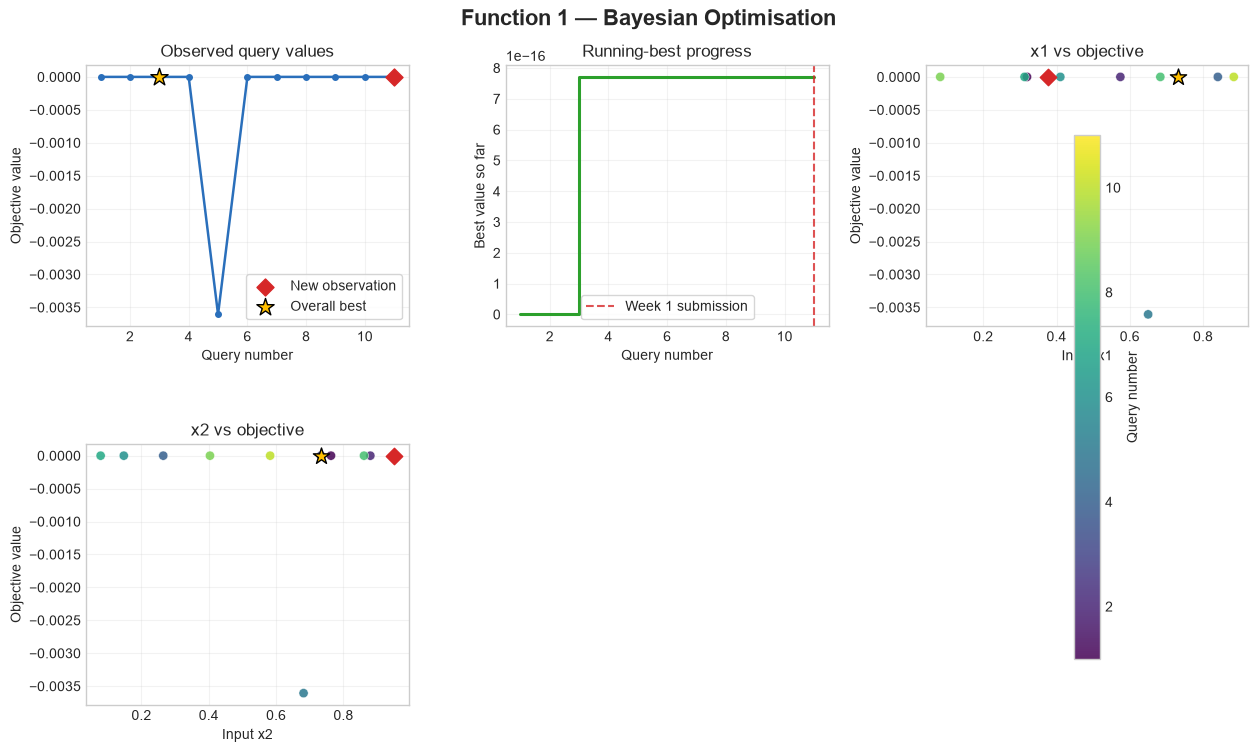

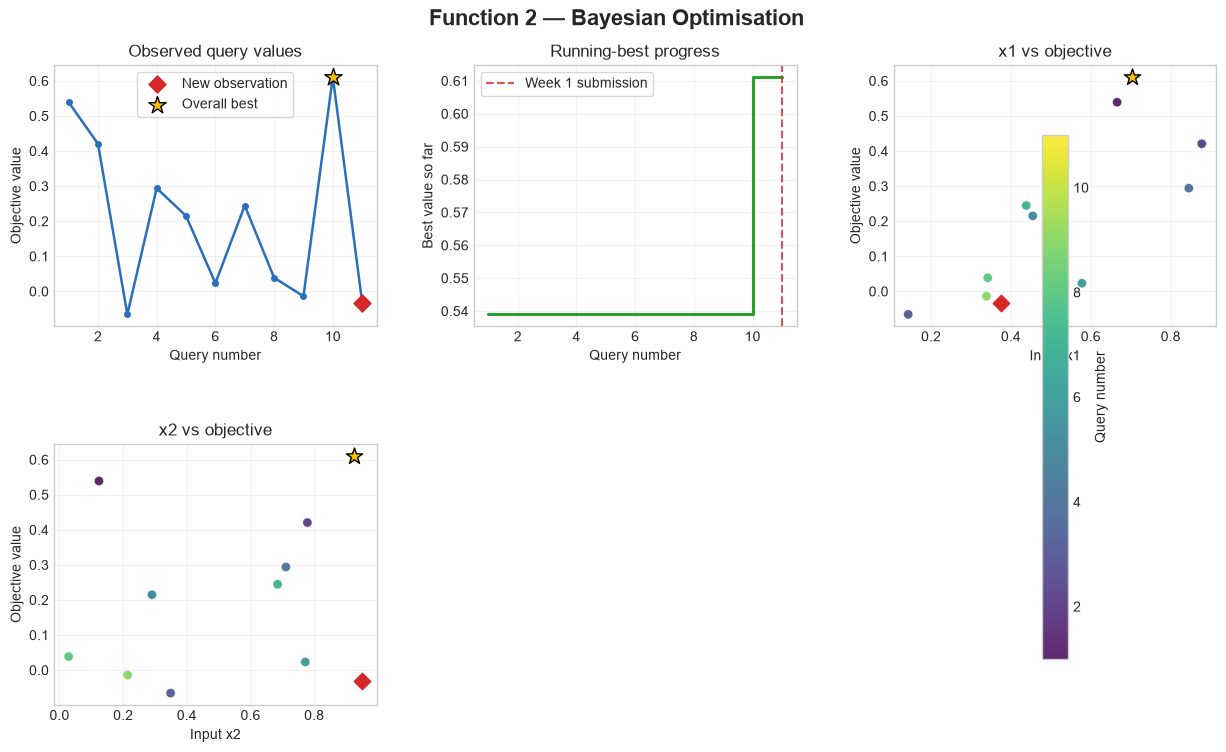

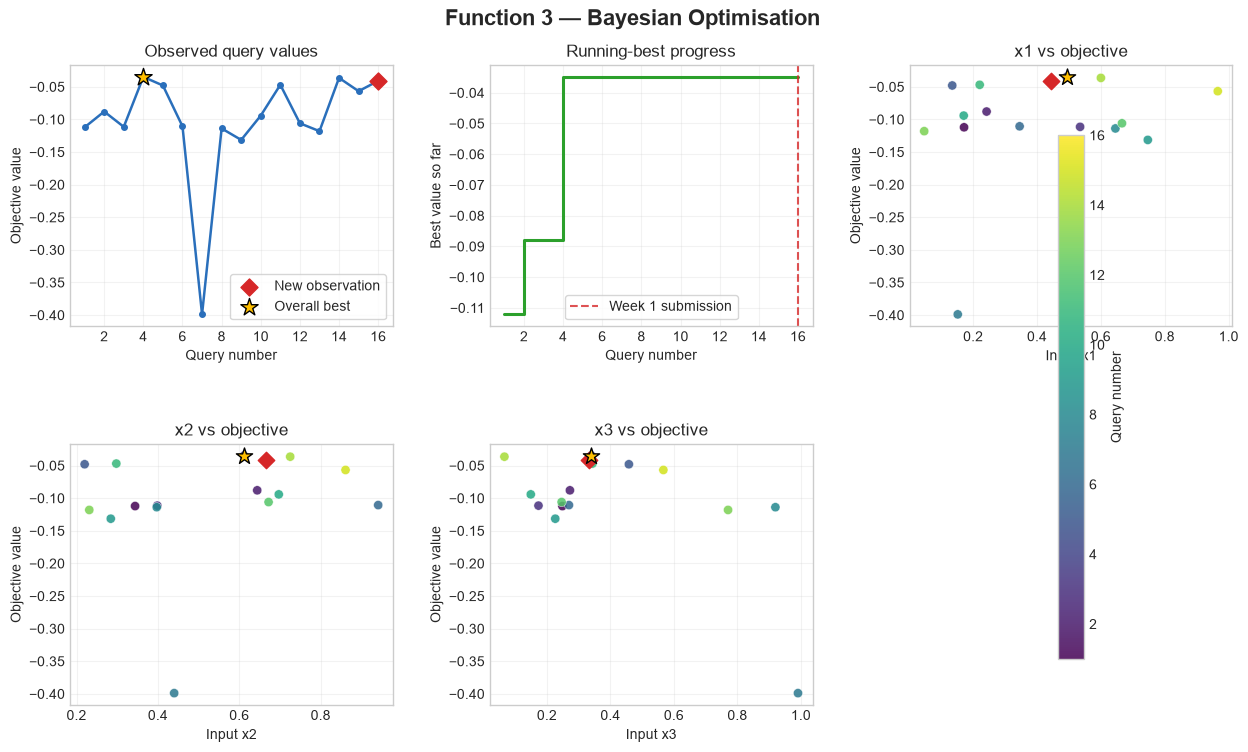

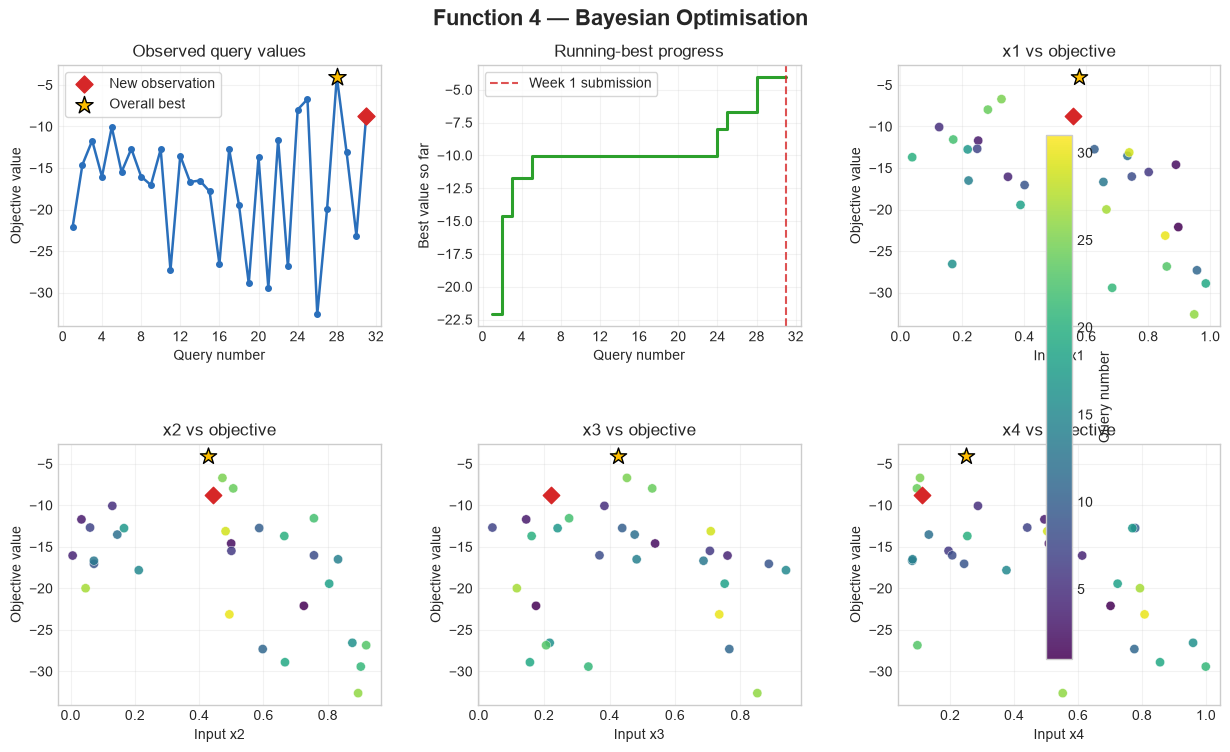

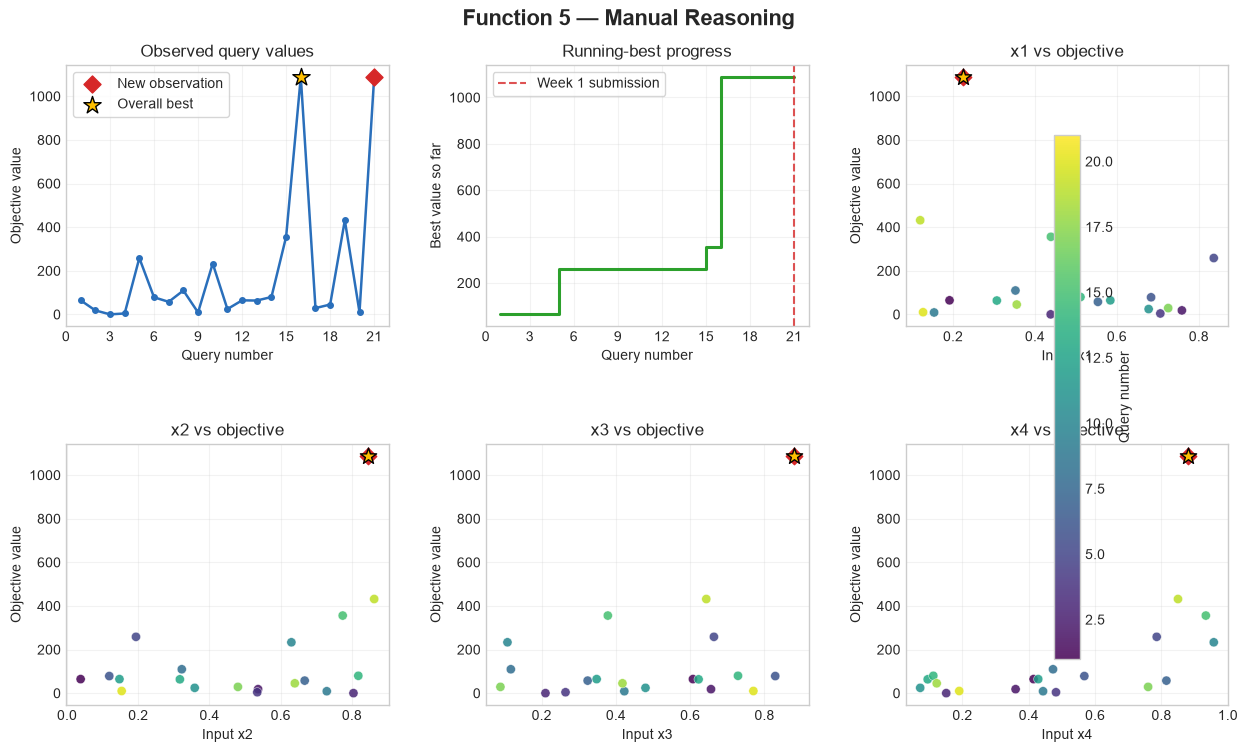

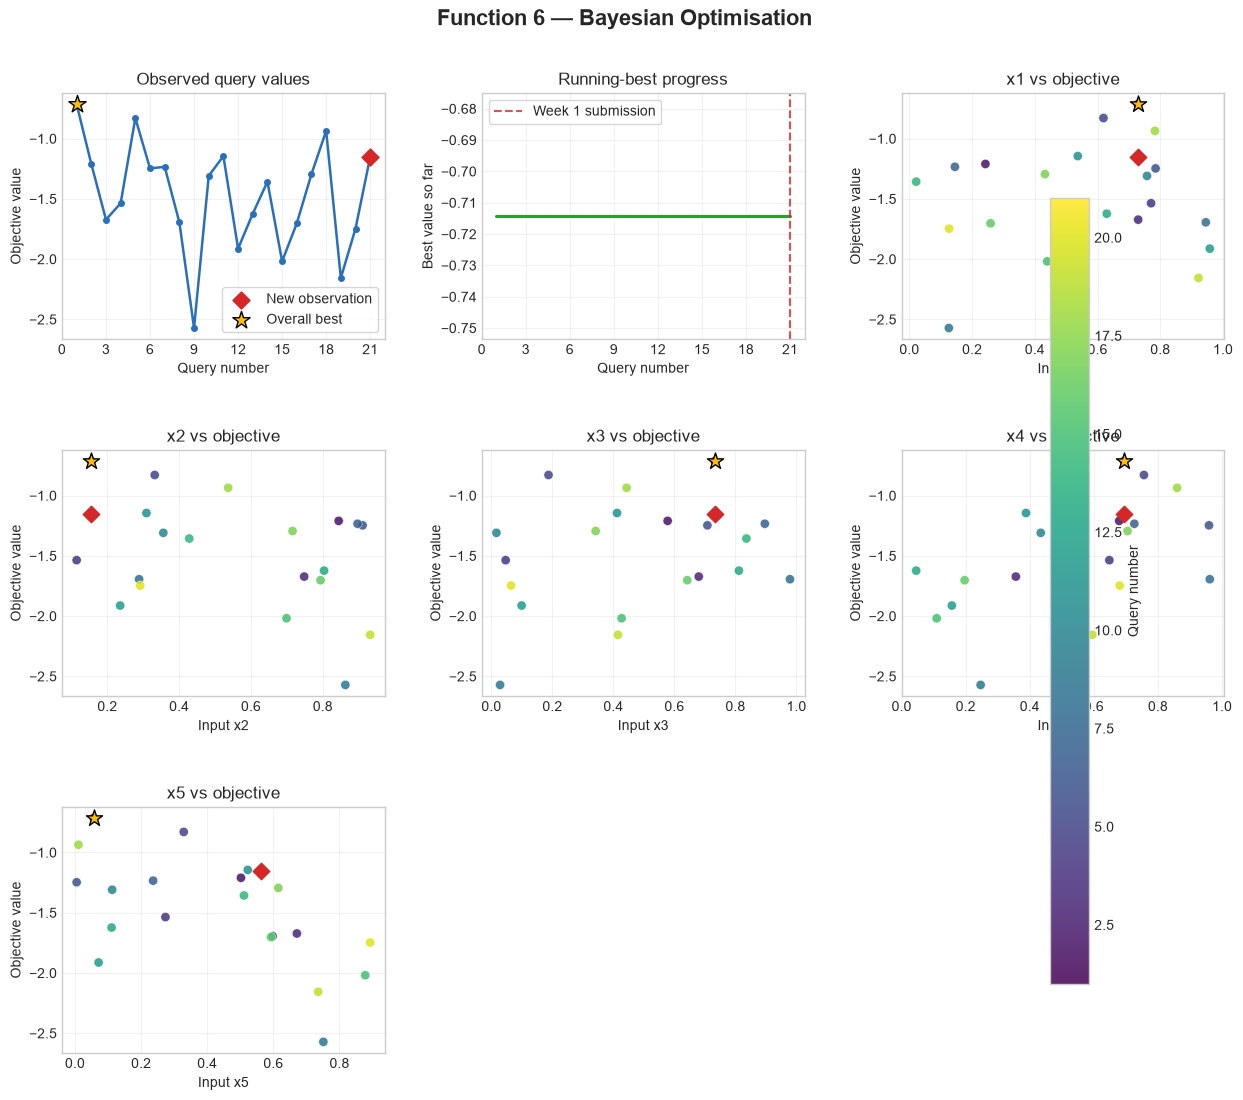

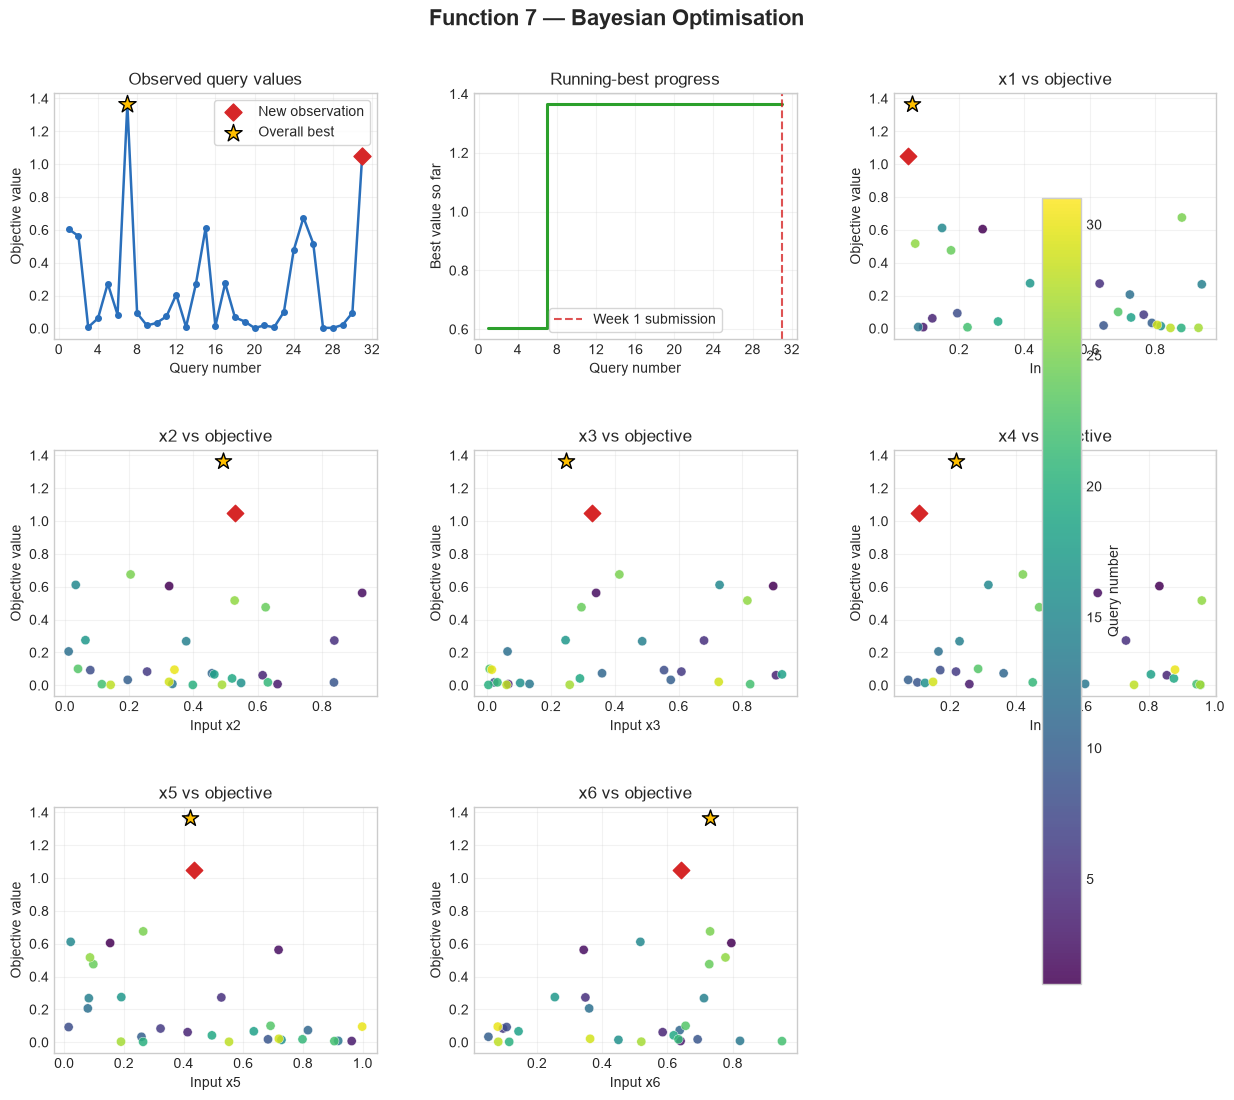

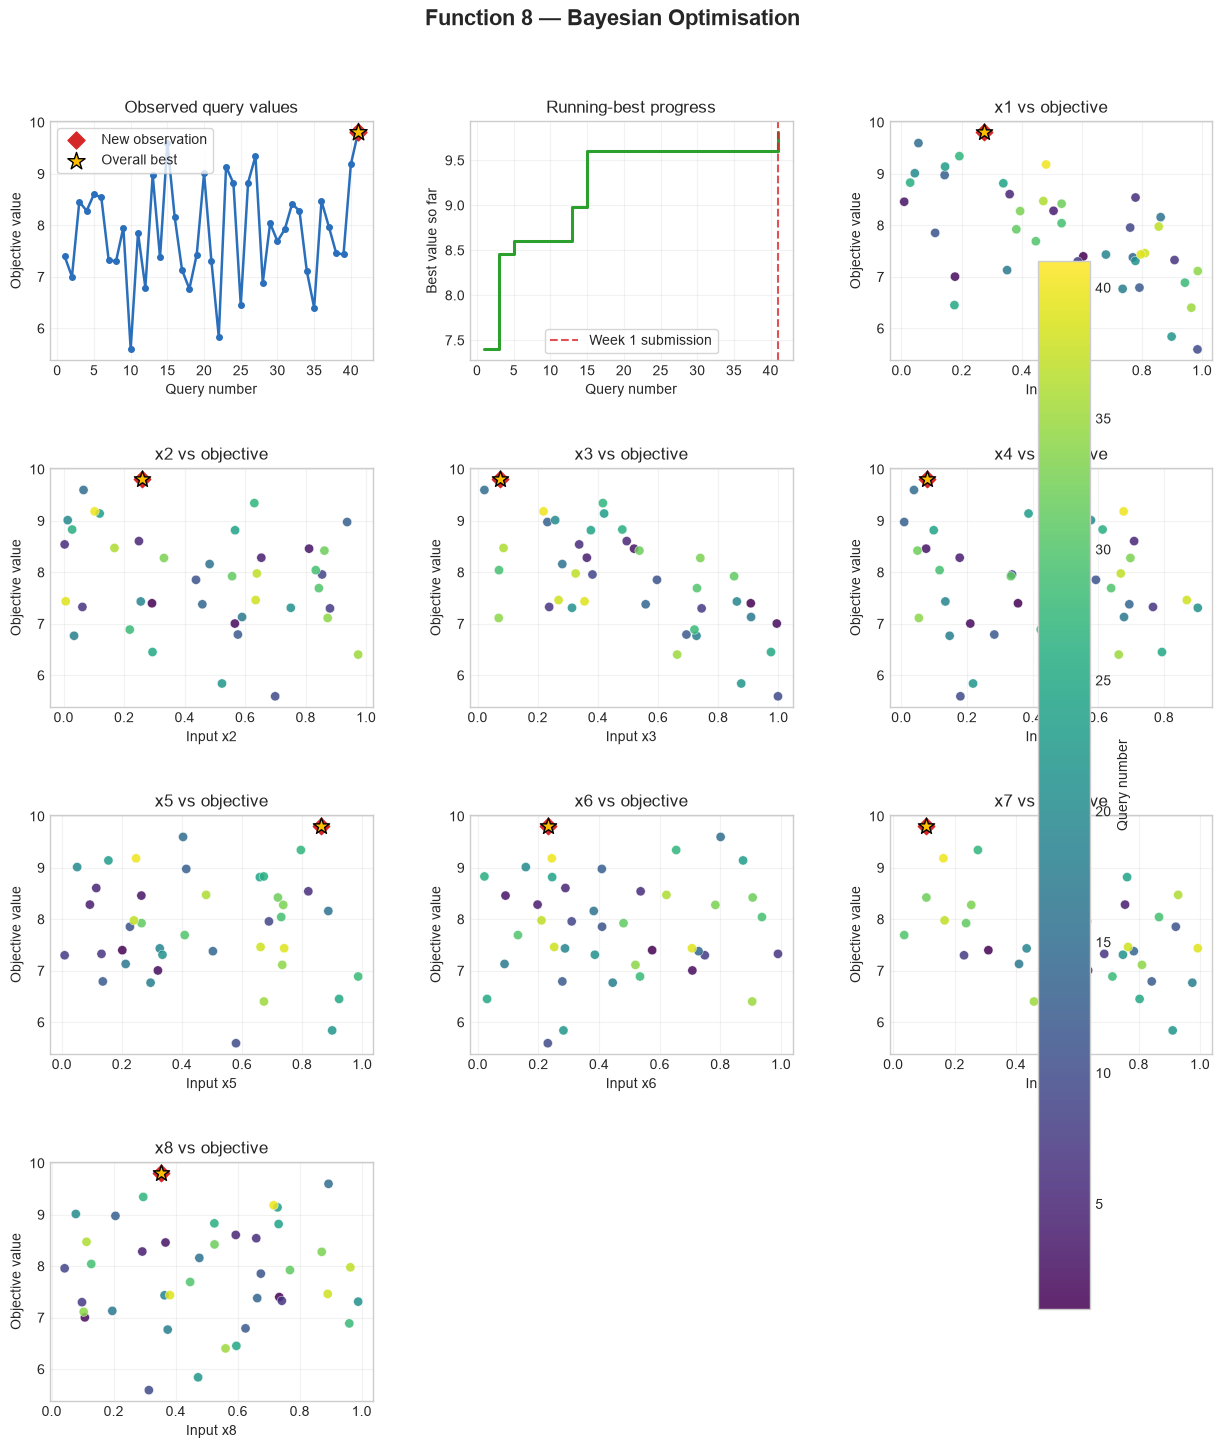

Rendered 8 function diagnostic figures.


In [7]:
def plot_function(function_number):
    X, y = load_week_2_data(function_number)
    queries = np.arange(1, y.size + 1)
    best_index = int(np.argmax(y))
    panel_count, columns = X.shape[1] + 2, 3
    rows = math.ceil(panel_count / columns)
    figure, axes = plt.subplots(rows, columns, figsize=(15, 4 * rows), squeeze=False)
    axes = axes.ravel()

    axes[0].plot(queries, y, color='#2a6fbb', marker='o', linewidth=1.8, markersize=4)
    axes[0].scatter(queries[-1], y[-1], marker='D', color='#d62728', s=75, zorder=4, label='New observation')
    axes[0].scatter(queries[best_index], y[best_index], marker='*', color='#ffbf00', edgecolor='black', s=170, zorder=5, label='Overall best')
    axes[0].set(xlabel='Query number', ylabel='Objective value', title='Observed query values')
    axes[0].xaxis.set_major_locator(MaxNLocator(integer=True))
    axes[0].legend(frameon=True)

    running_best = np.maximum.accumulate(y)
    axes[1].step(queries, running_best, where='post', color='#2ca02c', linewidth=2.2)
    axes[1].axvline(queries[-1], color='#d62728', linestyle='--', alpha=0.8, label='Week 1 submission')
    axes[1].set(xlabel='Query number', ylabel='Best value so far', title='Running-best progress')
    axes[1].xaxis.set_major_locator(MaxNLocator(integer=True))
    axes[1].legend(frameon=True)

    colour_scale = None
    for column, axis in enumerate(axes[2:2 + X.shape[1]]):
        colour_scale = axis.scatter(X[:, column], y, c=queries, cmap='viridis', s=44, alpha=0.85, edgecolor='white', linewidth=0.35)
        axis.scatter(X[-1, column], y[-1], marker='D', color='#d62728', s=70, zorder=4)
        axis.scatter(X[best_index, column], y[best_index], marker='*', color='#ffbf00', edgecolor='black', s=150, zorder=5)
        axis.set(xlabel=f'Input x{column + 1}', ylabel='Objective value', title=f'x{column + 1} vs objective')
    for axis in axes[panel_count:]:
        axis.set_visible(False)
    for axis in axes[:panel_count]:
        axis.grid(True, alpha=0.25)
    figure.colorbar(colour_scale, ax=axes[2:2 + X.shape[1]].tolist(), label='Query number', shrink=0.85)
    figure.suptitle(f'Function {function_number} — {STRATEGY[function_number]}', fontsize=16, fontweight='bold')
    figure.subplots_adjust(top=0.91, hspace=0.45, wspace=0.30)
    return figure

function_figures = [plot_function(i) for i in FUNCTION_NUMBERS]
plt.show()
print(f'Rendered {len(function_figures)} function diagnostic figures.')

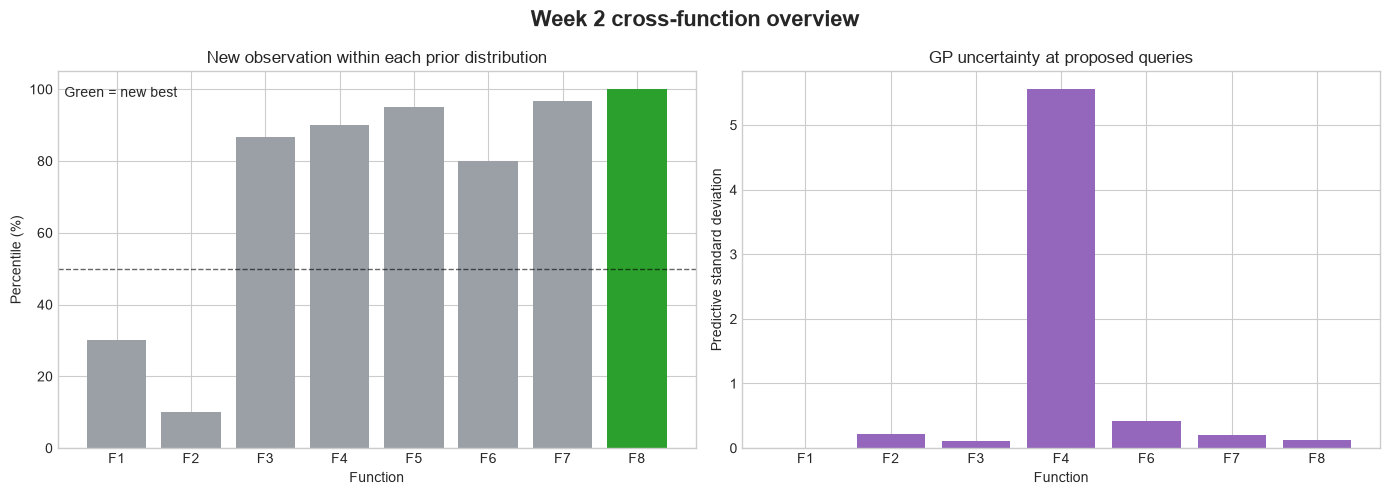

In [8]:
figure, axes = plt.subplots(1, 2, figsize=(14, 5))
labels = performance_summary['Function']
percentiles = performance_summary['New-observation percentile']
colours = np.where(performance_summary['Improvement'] > 0, '#2ca02c', '#9aa0a6')
axes[0].bar(labels, percentiles, color=colours)
axes[0].axhline(50, color='black', linestyle='--', linewidth=1, alpha=0.6)
axes[0].set(title='New observation within each prior distribution', ylabel='Percentile (%)', xlabel='Function', ylim=(0, 105))
axes[0].text(0.01, 0.96, 'Green = new best', transform=axes[0].transAxes, va='top')

gp_rows = proposal_summary['Method'].eq('Bayesian Optimisation')
axes[1].bar(proposal_summary.loc[gp_rows, 'Function'], proposal_summary.loc[gp_rows, 'Predictive std'], color='#9467bd')
axes[1].set(title='GP uncertainty at proposed queries', ylabel='Predictive standard deviation', xlabel='Function')
figure.suptitle('Week 2 cross-function overview', fontsize=16, fontweight='bold')
figure.tight_layout()
plt.show()

<a id="reproducibility-checks"></a>
## 10. Reproducibility checks

In [9]:
expected_counts = {1: 11, 2: 11, 3: 16, 4: 31, 5: 21, 6: 21, 7: 31, 8: 41}
for function_number in FUNCTION_NUMBERS:
    X, y = load_week_2_data(function_number)
    summary = summarize_function(function_number)
    assert X.shape == (expected_counts[function_number], EXPECTED_DIMENSIONS[function_number])
    assert y.shape == (expected_counts[function_number],)
    assert np.allclose(X[-1], WEEK_1_QUERIES[function_number])
    assert np.isclose(y[-1], WEEK_1_OUTPUTS[function_number])
    assert summary['Best query'] == int(np.argmax(y)) + 1
    assert np.isclose(summary['New best'], np.max(y))
    assert summary['Improvement'] >= 0.0
    assert function_number in submission_queries

assert len(performance_summary) == len(proposal_summary) == 8
assert sum(expected_counts.values()) == 183
assert set(submission_queries) == set(FUNCTION_NUMBERS)
print('All Week 2 data, performance, proposal, and plotting checks passed.')

All Week 2 data, performance, proposal, and plotting checks passed.


<a id="conclusions-next-steps"></a>
## 11. Conclusions and next steps

The validated Week 2 workflow preserves observed evidence separately from proposed next queries and provides the handoff to the following round.